In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Análise de Componentes Principais no Conjunto de Dados Breast Cancer Wisconsin

## Objetivo
O objetivo deste estudo é aplicar a Análise de Componentes Principais (PCA) no conjunto de dados *Breast Cancer Wisconsin* e analisar como as componentes principais se comportam para cada tipo de câncer presente no conjunto de dados. A análise visa compreender a variabilidade dos dados e reduzir a dimensionalidade, preservando ao máximo a informação relevante para classificação.

## Passos da Análise
1. **Carregamento do conjunto de dados**: Utiliza-se a base de dados *Breast Cancer Wisconsin* disponível no *Scikit-learn*.
2. **Pré-processamento dos dados**: Padronização das variáveis para que possuam média zero e variância unitária.
3. **Aplicação do PCA**: Cálculo das componentes principais e seleção da quantidade ideal de componentes com base na variância explicada.
4. **Visualização dos resultados**:
   - Gráfico da variância explicada acumulada.
   - Projeção dos dados nas componentes principais para observação da separabilidade entre os tipos de câncer.
5. **Interpretação das componentes**: Análise dos pesos das variáveis originais nas componentes principais para entender quais características têm maior influência na distribuição dos dados.


In [3]:
df = pd.read_csv("/content/data-2.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
df=df.drop(columns=['id', 'Unnamed: 32'])
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


* O conjunto de dados apresenta estar levemente desbalanceado

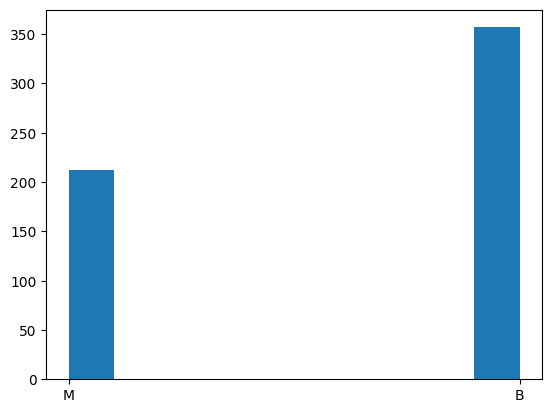

In [10]:
plt.hist(df["diagnosis"]);

* Não existem valores faltantes no conjunto dedados.

In [13]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


In [18]:
features = df.drop(['diagnosis'], axis=1)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(features)

features_transformed = scaler.transform(features)

In [32]:
features_transformed.shape

(569, 30)

In [25]:
from sklearn.decomposition import PCA

$$
Var_{explanied} = \frac{\lambda_i}{\sum \lambda}
$$

In [63]:
def plot_exaplined_variance(features):
  explained_variance =[]
  n_components =  lambda: [x for x in range(12)]
  for components in n_components():
    pca = PCA(n_components=components)
    pca.fit(features)
    explained_variance.append(sum(pca.explained_variance_ratio_))

  plt.plot(n_components(),explained_variance,marker="*")
  plt.xlabel("Components")
  plt.ylabel("Explained variance")


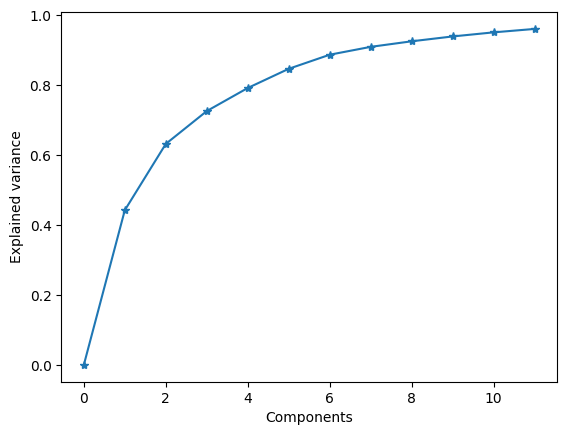

In [64]:
plot_exaplined_variance(features_transformed)

In [65]:
def apply_pca(features, number_components):
  pca = PCA(n_components=number_components)
  pca.fit(features)
  x_pca = pca.transform(features)
  return x_pca

In [66]:
features_pca=apply_pca(features_transformed,10)

In [67]:
def diag(x):
    if x =='M':
        return 1
    else:
        return 0
df_diag= df['diagnosis'].apply(diag)

In [68]:
import seaborn as sns

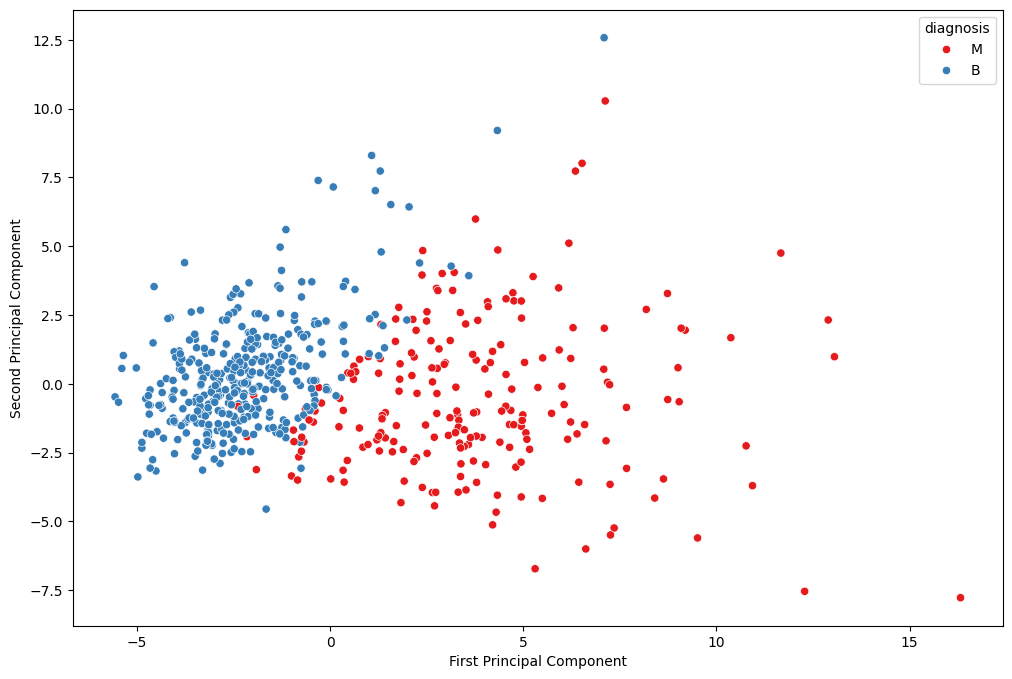

In [74]:
plt.figure(figsize=(12, 8))
sns.scatterplot(x=features_pca[:, 0], y=features_pca[:, 1], hue=df['diagnosis'], palette='Set1')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')

plt.show()

## Referências  

- IBM. *Análise de Componentes Principais (PCA)*. Disponível em: [https://www.ibm.com/br-pt/topics/principal-component-analysis#:~:text=A%20análise%20de%20componentes%20principais%20é%20comumente%20usado%20para%20pré,do%20conjunto%20de%20dados%20inicial](https://www.ibm.com/br-pt/topics/principal-component-analysis#:~:text=A%20análise%20de%20componentes%20principais%20é%20comumente%20usado%20para%20pré,do%20conjunto%20de%20dados%20inicial). Acesso em: [data do acesso].

- UCI Machine Learning Repository. *Breast Cancer Wisconsin (Diagnostic) Data Set*. Disponível em: [https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic](https://archive.ics.uci.edu/dataset/17/breast+cancer+
